# DSA Survey Strategy Demonstration

This notebook demonstrates two scanning strategies for DSA single-dish mode:

1. **MeerKLASS-type**: Constant-elevation azimuthal back-and-forth scans
2. **Stop-and-stare (steering-and-shift)**: Track fixed (RA, Dec) positions, then shift to next pointing

We focus on visualizing the scan patterns and coordinate conversions before running the full TOD simulation.

In [1]:
import sys, os
# Ensure limTOD and the local dsa_vis helpers are importable.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord, AltAz, EarthLocation
from astropy.time import Time, TimeDelta
import astropy.units as u
import healpy as hp

# Site constants + tracking helper now live in dsa_vis so all three
# DSA notebooks share one definition.
from dsa_vis import DSA_LAT, DSA_LON, DSA_HGT, radec_to_azel

dsa_location = EarthLocation(lat=DSA_LAT*u.deg, lon=DSA_LON*u.deg, height=DSA_HGT*u.m)
print(f"DSA location: lat={DSA_LAT}°, lon={DSA_LON}°, height={DSA_HGT} m")

DSA location: lat=39.553969°, lon=-114.423973°, height=1746.51 m


## Core idea: How to convert (RA, Dec) → (Az, El) for stop-and-stare

When a telescope **tracks** a fixed sky position (RA, Dec), the Earth's rotation causes the target to move across the local sky. At each moment, the target has different (Az, El) coordinates.

The conversion chain:
```
Fixed target (RA, Dec)  +  Observatory (lat, lon, height)  +  Time (UTC)
    ↓
    astropy coordinate transform
    ↓
Instantaneous (Az, El) at that moment
```

This is what `radec_to_azel()` does below.

In [2]:
# radec_to_azel is imported from dsa_vis (cell above). Demonstrate with a
# single stop-and-stare pointing: target RA=180°, Dec=30° tracked for 21 min.
ra_target, dec_target = 180.0, 30.0

# Observe for 21 minutes (CASS standard pointing duration), sampling every 2s
dt = 2.0  # seconds
t_pointing = 21 * 60  # 21 minutes in seconds
time_list = np.arange(0, t_pointing, dt)

# Choose a start time when the target is near transit
start_time = "2024-04-15 04:00:00"

az, el = radec_to_azel(ra_target, dec_target, time_list, start_time, dsa_location)

print(f"Target: RA={ra_target}°, Dec={dec_target}°")
print(f"Duration: {t_pointing/60:.0f} min, {len(time_list)} samples at dt={dt}s")
print(f"Az range: [{az.min():.2f}°, {az.max():.2f}°]")
print(f"El range: [{el.min():.2f}°, {el.max():.2f}°]")

Target: RA=180.0°, Dec=30.0°
Duration: 21 min, 630 samples at dt=2.0s
Az range: [101.39°, 106.85°]
El range: [62.95°, 66.88°]


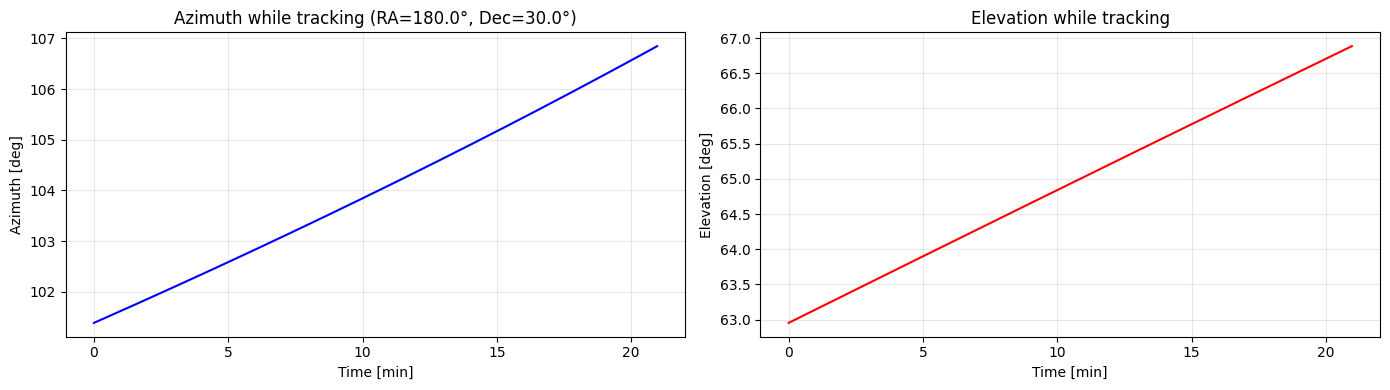

Key insight: Both Az and El change smoothly during a 21-min tracking observation.
This is what limTOD's generate_TOD receives as azimuth_deg_list and elevation_deg (as a list).


In [3]:
# Plot Az and El as functions of time for the single tracking pointing
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(time_list / 60, az, 'b-', lw=1.5)
axes[0].set_xlabel('Time [min]')
axes[0].set_ylabel('Azimuth [deg]')
axes[0].set_title(f'Azimuth while tracking (RA={ra_target}°, Dec={dec_target}°)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_list / 60, el, 'r-', lw=1.5)
axes[1].set_xlabel('Time [min]')
axes[1].set_ylabel('Elevation [deg]')
axes[1].set_title(f'Elevation while tracking')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight: Both Az and El change smoothly during a 21-min tracking observation.")
print("This is what limTOD's generate_TOD receives as azimuth_deg_list and elevation_deg (as a list).")

## Stop-and-Stare Mosaic: Multiple Pointings in a Hex Pattern

Following the DSA CASS survey design (Modified Hexagonal Pattern) and the uGMRT flower pattern (Elahi et al. 2025, Fig. 2):
- Arrange pointing centers in a hexagonal grid
- Each pointing is observed for 21 minutes
- Overlap between pointings ensures uniform sensitivity across the mosaic

For single-dish mode with a ~5° FWHM beam, we use ~3.5° spacing (so beams overlap significantly).

In [4]:
# Define a 3x3 hexagonal pointing grid
# Center at Dec~52° to match the north-facing MeerKLASS scans
# Spacing chosen so adjacent beams overlap by ~28% of the FWHM (4.85°):
#   d_dec = 3.5° => overlap = 4.85 - 3.5 = 1.35° (28% of FWHM)
#   Diagonal neighbor distance = sqrt(3.5² + 1.75²) ≈ 3.91° => 19% overlap
# This is close to the optimal ~30% overlap for uniform mosaic sensitivity.
center_ra, center_dec = 180.0, 52.0
d_dec = 3.5  # Dec spacing in degrees
d_ra  = 3.5 / np.cos(np.radians(center_dec))  # RA coord spacing; on-sky distance is 3.5°

pointings = []
for i_row, dec_offset in enumerate([-d_dec, 0, d_dec]):
    ra_shift = d_ra / 2 if i_row % 2 == 1 else 0  # hex offset for odd rows
    for ra_offset in [-d_ra, 0, d_ra]:
        pointings.append((center_ra + ra_offset + ra_shift, center_dec + dec_offset))

pointings = np.array(pointings)
print(f"Number of pointings: {len(pointings)}")
print(f"RA range:  [{pointings[:,0].min():.1f}°, {pointings[:,0].max():.1f}°]")
print(f"Dec range: [{pointings[:,1].min():.1f}°, {pointings[:,1].max():.1f}°]")
print(f"Beam FWHM: 4.85°, spacing: {d_dec}° => {(1 - d_dec/4.85)*100:.0f}% overlap")
print("\nPointing centers (RA, Dec):")
for i, (ra, dec) in enumerate(pointings):
    print(f"  PC {i}: ({ra:.2f}°, {dec:.2f}°)")

Number of pointings: 9
RA range:  [174.3°, 188.5°]
Dec range: [48.5°, 55.5°]
Beam FWHM: 4.85°, spacing: 3.5° => 28% overlap

Pointing centers (RA, Dec):
  PC 0: (174.32°, 48.50°)
  PC 1: (180.00°, 48.50°)
  PC 2: (185.68°, 48.50°)
  PC 3: (177.16°, 52.00°)
  PC 4: (182.84°, 52.00°)
  PC 5: (188.53°, 52.00°)
  PC 6: (174.32°, 55.50°)
  PC 7: (180.00°, 55.50°)
  PC 8: (185.68°, 55.50°)


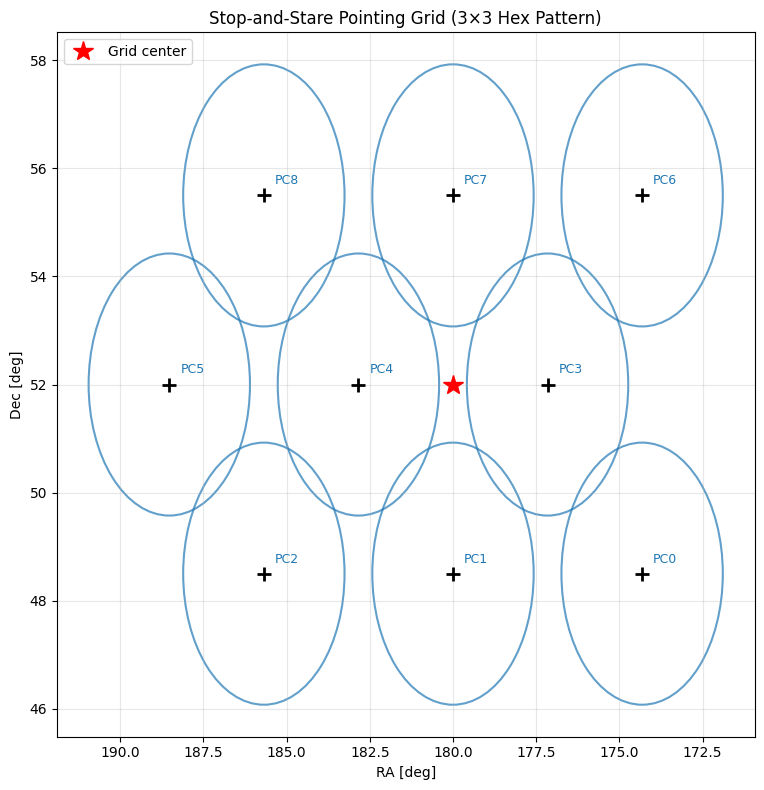

In [5]:
# Visualize the pointing grid with beam footprints
fig, ax = plt.subplots(figsize=(10, 8))

beam_fwhm = 4.85  # degrees (from the DSA beam FITS file)

for i, (ra, dec) in enumerate(pointings):
    circle = plt.Circle((ra, dec), beam_fwhm/2, fill=False, color='C0', lw=1.5, alpha=0.7)
    ax.add_patch(circle)
    ax.plot(ra, dec, 'k+', ms=10, mew=2)
    ax.annotate(f'PC{i}', (ra, dec), textcoords="offset points", 
                xytext=(8, 8), fontsize=9, color='C0')

# Mark center
ax.plot(center_ra, center_dec, 'r*', ms=15, label='Grid center')

ax.set_xlabel('RA [deg]')
ax.set_ylabel('Dec [deg]')
ax.set_title('Stop-and-Stare Pointing Grid (3×3 Hex Pattern)')
ax.set_aspect(1/np.cos(np.radians(center_dec)))
ax.invert_xaxis()  # RA increases to the left
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

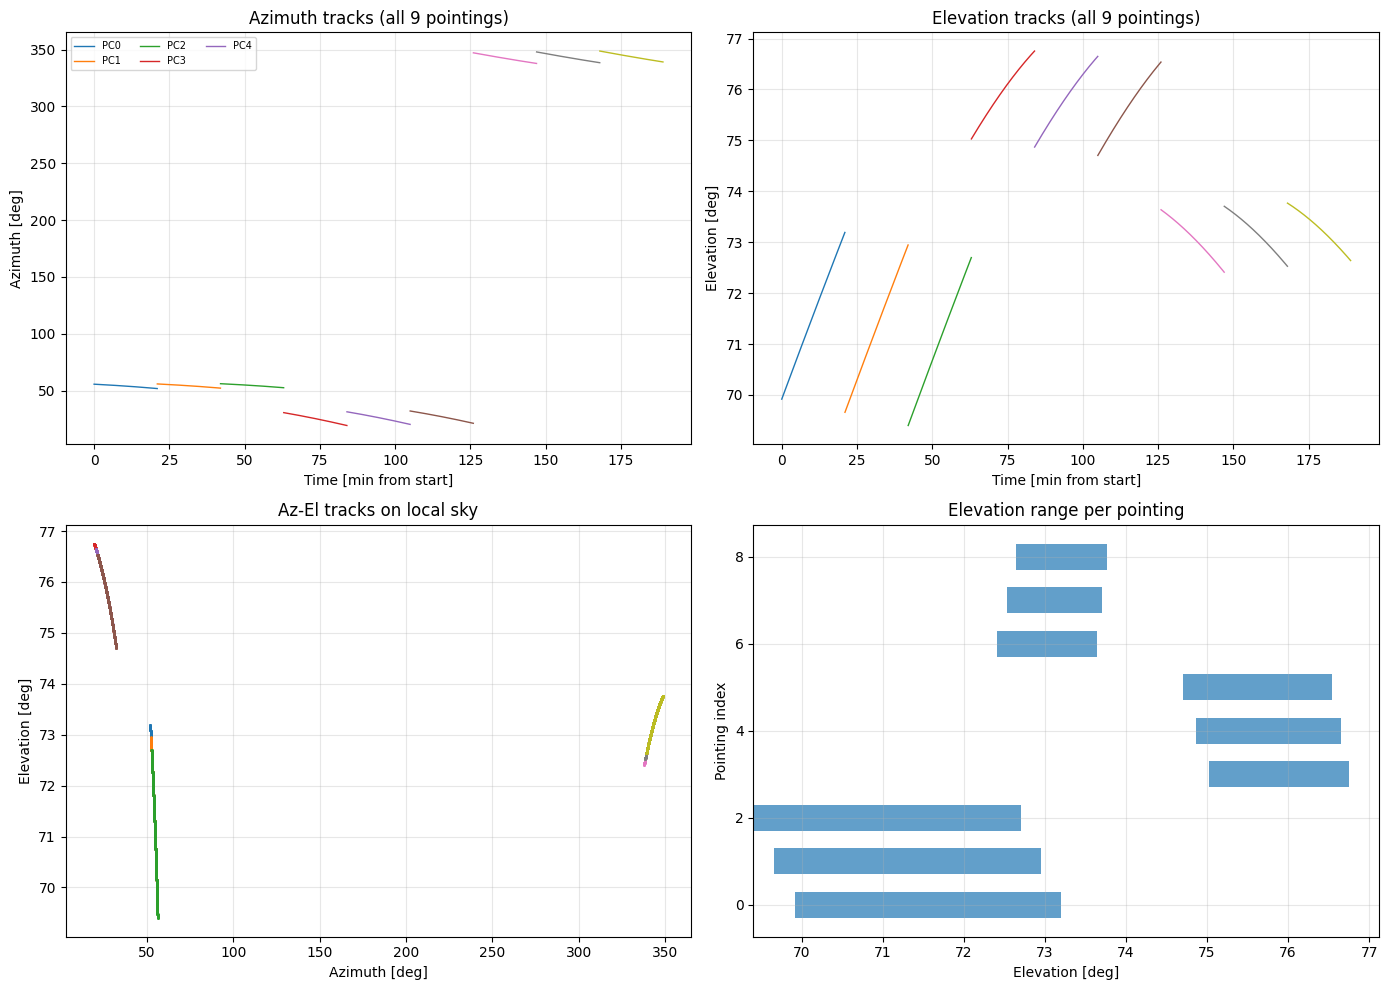


Total observation time: 3.1 hours
Total samples: 5670
Min elevation across all pointings: 69.4°
Max elevation across all pointings: 76.8°


In [6]:
# Compute Az/El tracks for ALL 9 pointings (sequential, 21 min each)
base_start = "2024-04-15 04:00:00"
t_per_pointing = 21 * 60  # 21 minutes in seconds
dt = 2.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

all_az = []
all_el = []

for i, (ra_i, dec_i) in enumerate(pointings):
    # Each pointing starts after the previous one ends
    start_i = (Time(base_start) + TimeDelta(i * t_per_pointing, format='sec')).iso
    time_list_i = np.arange(0, t_per_pointing, dt)
    
    az_i, el_i = radec_to_azel(ra_i, dec_i, time_list_i, start_i, dsa_location)
    all_az.append(az_i)
    all_el.append(el_i)
    
    # Plot Az vs time
    t_offset_min = i * t_per_pointing / 60  # global time offset in minutes
    t_global = time_list_i / 60 + t_offset_min
    
    axes[0, 0].plot(t_global, az_i, lw=1, label=f'PC{i}' if i < 5 else None)
    axes[0, 1].plot(t_global, el_i, lw=1)
    
    # Verify source is above horizon
    if el_i.min() < 10:
        print(f"WARNING: PC{i} (RA={ra_i:.1f}, Dec={dec_i:.1f}) drops below 10° elevation!")

axes[0, 0].set_xlabel('Time [min from start]')
axes[0, 0].set_ylabel('Azimuth [deg]')
axes[0, 0].set_title('Azimuth tracks (all 9 pointings)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(fontsize=7, ncol=3)

axes[0, 1].set_xlabel('Time [min from start]')
axes[0, 1].set_ylabel('Elevation [deg]')
axes[0, 1].set_title('Elevation tracks (all 9 pointings)')
axes[0, 1].grid(True, alpha=0.3)

# Plot Az vs El for each pointing (shows the track on the local sky)
for i in range(len(pointings)):
    axes[1, 0].plot(all_az[i], all_el[i], 'o-', ms=1, lw=0.5, label=f'PC{i}')
axes[1, 0].set_xlabel('Azimuth [deg]')
axes[1, 0].set_ylabel('Elevation [deg]')
axes[1, 0].set_title('Az-El tracks on local sky')
axes[1, 0].grid(True, alpha=0.3)

# Summary statistics
el_mins = [e.min() for e in all_el]
el_maxs = [e.max() for e in all_el]
axes[1, 1].barh(range(len(pointings)), 
                [mx - mn for mn, mx in zip(el_mins, el_maxs)],
                left=el_mins, height=0.6, color='C0', alpha=0.7)
axes[1, 1].set_xlabel('Elevation [deg]')
axes[1, 1].set_ylabel('Pointing index')
axes[1, 1].set_title('Elevation range per pointing')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary
print(f"\nTotal observation time: {len(pointings) * t_per_pointing / 3600:.1f} hours")
print(f"Total samples: {sum(len(a) for a in all_az)}")
print(f"Min elevation across all pointings: {min(el_mins):.1f}°")
print(f"Max elevation across all pointings: {max(el_maxs):.1f}°")

## How this feeds into limTOD

For each pointing, we pass the Az/El arrays directly to `TODSim.generate_TOD()`:

```python
tod_array, _, _, LSTs = tod_sim.generate_TOD(
    freq_list=[1000],
    time_list=time_list_i,           # 0, 2, 4, ..., 1258 seconds
    azimuth_deg_list=az_i,           # time-varying Az array
    elevation_deg=el_i,              # time-varying El array (LIST, not scalar!)
    start_time_utc=start_time_i,     # absolute UTC start of this pointing
    return_LSTs=True,
    ...
)
```

**Key difference from MeerKLASS scanning**: `elevation_deg` is a **list** (per-sample), not a scalar. limTOD supports this natively (see `simulator.py` line 738-740).

---

## Comparison: MeerKLASS-type Scan Pattern

For reference, here is the MeerKLASS-style constant-elevation scanning pattern that would cover a similar sky area.

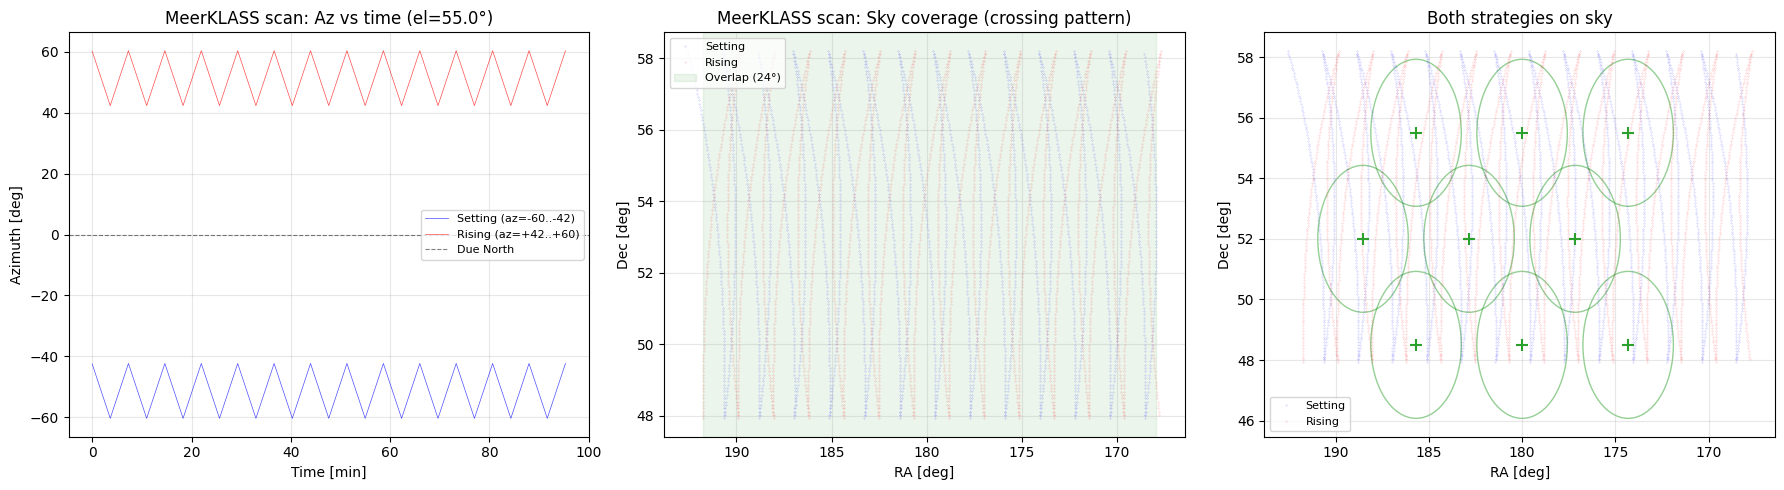

MeerKLASS scans:
  Setting: RA=[167.9, 192.6], Dec=[47.9, 58.2]
  Rising:  RA=[167.7, 191.7], Dec=[47.9, 58.2]
  RA overlap: 23.8°, centered at RA≈179.8°
  Dec range: [47.9, 58.2] = 10.3°
  Total: 5720 samples, 191 min

Stop-and-stare: RA=[174.3, 188.5], Dec=[48.5, 55.5], 5670 samples, 189 min


In [7]:
from limTOD import example_scan
from limTOD.simulator import generate_LSTs_deg

# MeerKLASS-type scan: constant elevation, back-and-forth in azimuth
#
# From DSA (lat=39.55°), face NORTH at el=55° to observe Dec~53°.
# Zenith angle = 35° gives ~10° Dec coverage and ~25° RA coverage —
# closer to a typical IM survey strip than the wider el=45° geometry,
# with deeper integration per beam.
#
# Two crossing scans with mirrored azimuths (exactly as mm_example):
#   Setting: az = -60.3..-42.3 (west of north, source past transit)
#   Rising:  az = +42.3..+60.3 (east of north, source before transit)
# Start times tuned so both hit RA~180° and overlap.

el_scan = 55.0

# Setting scan (source is west of north, past transit)
time_setting, az_setting = example_scan(az_s=-60.3, az_e=-42.3, dt=2.0, n_repeats=13)
start_setting = "2024-04-15 08:25:05"  # tuned so RA-mean = 180°

# Rising scan (source is east of north, before transit)
time_rising, az_rising = example_scan(az_s=42.3, az_e=60.3, dt=2.0, n_repeats=13)
start_rising = "2024-04-15 02:03:50"   # tuned so RA-mean = 180°

# Convert scan patterns to RA/Dec
def azel_to_radec(az_deg, el_deg, time_list_sec, start_time_utc, location):
    """Convert (Az, El) + time arrays to (RA, Dec) for each sample."""
    start = Time(start_time_utc)
    times = start + TimeDelta(time_list_sec, format='sec')
    altaz = AltAz(obstime=times, location=location, az=az_deg*u.deg, alt=el_deg*u.deg)
    icrs = SkyCoord(altaz).icrs
    return icrs.ra.deg, icrs.dec.deg

ra_set, dec_set = azel_to_radec(az_setting, el_scan, time_setting, start_setting, dsa_location)
ra_ris, dec_ris = azel_to_radec(az_rising, el_scan, time_rising, start_rising, dsa_location)

# Compute RA overlap
ov_lo = max(ra_set.min(), ra_ris.min())
ov_hi = min(ra_set.max(), ra_ris.max())
ra_overlap = max(0, ov_hi - ov_lo)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Az vs time
axes[0].plot(time_setting/60, az_setting, 'b-', lw=0.5, alpha=0.7, label='Setting (az=-60..-42)')
axes[0].plot(time_rising/60, az_rising, 'r-', lw=0.5, alpha=0.7, label='Rising (az=+42..+60)')
axes[0].axhline(0, color='k', ls='--', lw=0.8, alpha=0.5, label='Due North')
axes[0].set_xlabel('Time [min]')
axes[0].set_ylabel('Azimuth [deg]')
axes[0].set_title(f'MeerKLASS scan: Az vs time (el={el_scan}°)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# RA/Dec coverage
axes[1].plot(ra_set, dec_set, 'b.', ms=0.5, alpha=0.3, label='Setting')
axes[1].plot(ra_ris, dec_ris, 'r.', ms=0.5, alpha=0.3, label='Rising')
axes[1].axvspan(ov_lo, ov_hi, alpha=0.08, color='green', label=f'Overlap ({ra_overlap:.0f}°)')
axes[1].set_xlabel('RA [deg]')
axes[1].set_ylabel('Dec [deg]')
axes[1].set_title('MeerKLASS scan: Sky coverage (crossing pattern)')
axes[1].invert_xaxis()
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Overlay stop-and-stare footprints
axes[2].plot(ra_set, dec_set, 'b.', ms=0.5, alpha=0.3, label='Setting')
axes[2].plot(ra_ris, dec_ris, 'r.', ms=0.5, alpha=0.3, label='Rising')
for i, (ra_p, dec_p) in enumerate(pointings):
    circle = plt.Circle((ra_p, dec_p), beam_fwhm/2, fill=False, color='C2', lw=1, alpha=0.5)
    axes[2].add_patch(circle)
    axes[2].plot(ra_p, dec_p, 'C2+', ms=8, mew=1.5)
axes[2].set_xlabel('RA [deg]')
axes[2].set_ylabel('Dec [deg]')
axes[2].set_title('Both strategies on sky')
axes[2].set_aspect(1/np.cos(np.radians(center_dec)))
axes[2].invert_xaxis()
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

all_dec = np.concatenate([dec_set, dec_ris])
all_ra = np.concatenate([ra_set, ra_ris])
print(f"MeerKLASS scans:")
print(f"  Setting: RA=[{ra_set.min():.1f}, {ra_set.max():.1f}], Dec=[{dec_set.min():.1f}, {dec_set.max():.1f}]")
print(f"  Rising:  RA=[{ra_ris.min():.1f}, {ra_ris.max():.1f}], Dec=[{dec_ris.min():.1f}, {dec_ris.max():.1f}]")
print(f"  RA overlap: {ra_overlap:.1f}°, centered at RA≈{(ov_lo+ov_hi)/2:.1f}°")
print(f"  Dec range: [{all_dec.min():.1f}, {all_dec.max():.1f}] = {all_dec.max()-all_dec.min():.1f}°")
print(f"  Total: {len(time_setting)+len(time_rising)} samples, {(len(time_setting)+len(time_rising))*2/60:.0f} min")
print(f"\nStop-and-stare: RA=[{pointings[:,0].min():.1f}, {pointings[:,0].max():.1f}], "
      f"Dec=[{pointings[:,1].min():.1f}, {pointings[:,1].max():.1f}], "
      f"5670 samples, 189 min")

## Summary of the two strategies

| Property | MeerKLASS scan | Stop-and-stare |
|----------|---------------|----------------|
| Pointing direction | **North** (az ~ ±50°) at el = 55° | Tracking fixed (RA,Dec) |
| Elevation | **Constant** (55°) | **Varying** per sample |
| Azimuth | Back-and-forth sweep | Smooth tracking |
| Sky coverage | Two crossing wedges (~25° RA × 10° Dec) | 9 circular patches |
| Crossing angles | Setting + Rising give 2 parallactic angles | Each pointing: 1 angle |
| Dec coverage | ~10° per scan, overlapping | 3 rows × 3.5° = 7° + beam |
| Total samples | 5720 (191 min) | 5670 (189 min) |
| `elevation_deg` in limTOD | `float` (scalar) | `list` (per-sample array) |

Both feed into `TODSim.generate_TOD()` and `HPW_mapmaking` identically.